<a href="https://colab.research.google.com/github/mvu2ab/trees/blob/main/assignment_(5).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment: Trees
Do three questions.

In [ ]:
!git clone https://github.com/mvu2ab/trees/tree/main

Cloning into 'main'...
fatal: repository 'https://github.com/mvu2ab/trees/tree/main/' not found


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models.

3. Why is the Gini a good loss function for categorical target variables?

4. Why do trees tend to overfit, and how can this tendency be constrained?

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates.

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. Trees are built by recursively splitting a dataset based on feature values that best differentiate target variable, typically by minimizing a loss function at each step until a stopping rule is met.

2. Non-linear relationships lend themselves to the creation of piecewise decision rules. linear models assume straight-line relationships.

3. The Gini is a good because it is fast and penalizes splits that result in mixed classes.

4. Keep splitting until perfectly fit training data. This can be constrained by limiting tree depth, minimum samples per split, pruning, or using ensemble methods like Random Forests.

5. False -- trees work will with both types of variables. Thye do not assume specific data types.

6. Binary splits are simpler to compute.

7. Very deep with many small brances or leaf nodes -- overfitting. Too shallow or low accuracy on training data -- underfitting.



**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see.

In [16]:
!git clone https://github.com/mvu2ab/trees.git


import pandas as pd

data = "trees/assignment/data/cars_hw.csv"
df = pd.read_csv(data)
print(f"Observations: {df.shape[0]}, Variables: {df.shape[1]}")

print(df.head())

fatal: destination path 'trees' already exists and is not an empty directory.
Observations: 976, Variables: 12
   Unnamed: 0        Make  Make_Year   Color  Body_Type  Mileage_Run  \
0           1  Volkswagen       2017  silver      sedan        44611   
1           2     Hyundai       2016     red  crossover        20305   
2           3       Honda       2019   white        suv        29540   
3           4     Renault       2017  bronze  hatchback        35680   
4           5     Hyundai       2017  orange  hatchback        25126   

  No_of_Owners  Seating_Capacity Fuel_Type Transmission Transmission_Type  \
0          1st                 5    diesel      7-Speed         Automatic   
1          1st                 5    petrol      5-Speed            Manual   
2          2nd                 5    petrol      5-Speed            Manual   
3          1st                 5    petrol      5-Speed            Manual   
4          1st                 5    petrol      5-Speed            Manu

In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split


categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target_var = 'Price'

df_encoded = pd.get_dummies(df[categorical_vars], drop_first=True)

X = pd.concat([df[numeric_vars], df_encoded], axis=1)
y = df[target_var]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)


X_train shape: (780, 45)
X_test shape: (196, 45)
y_train shape: (780,)
y_test shape: (196,)


Best min_samples_leaf: 5
Highest R² on test set: 0.8253410511223336


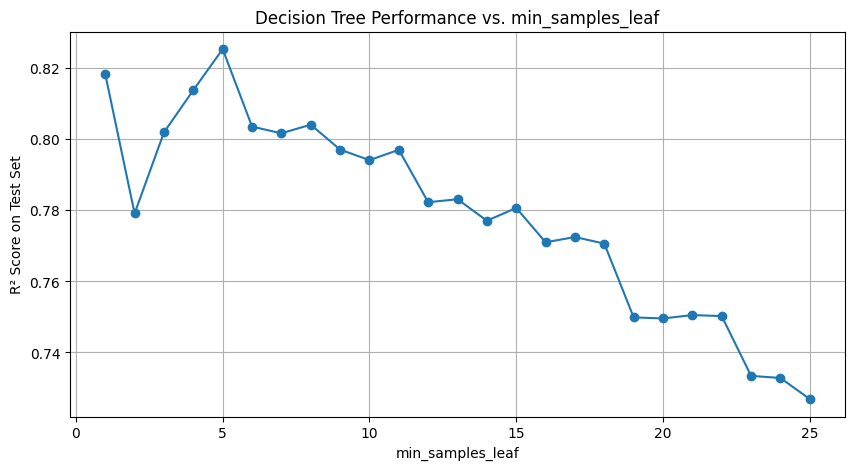

In [19]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


r2_scores = []


for leaf in range(1, 26):
    model = DecisionTreeRegressor(min_samples_leaf=leaf, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append(r2)


best_leaf = np.argmax(r2_scores) + 1
best_r2 = r2_scores[best_leaf - 1]


print("Best min_samples_leaf:", best_leaf)
print("Highest R² on test set:", best_r2)


plt.figure(figsize=(10, 5))
plt.plot(range(1, 26), r2_scores, marker='o')
plt.xlabel("min_samples_leaf")
plt.ylabel("R² Score on Test Set")
plt.title("Decision Tree Performance vs. min_samples_leaf")
plt.grid(True)
plt.show()


In [20]:
print("Best min_samples_leaf:", best_leaf)
print("Highest R² on test set:", best_r2)

Best min_samples_leaf: 5
Highest R² on test set: 0.8253410511223336


R² on test set: 0.8019082918926088
RMSE on test set: 150732.29268321928


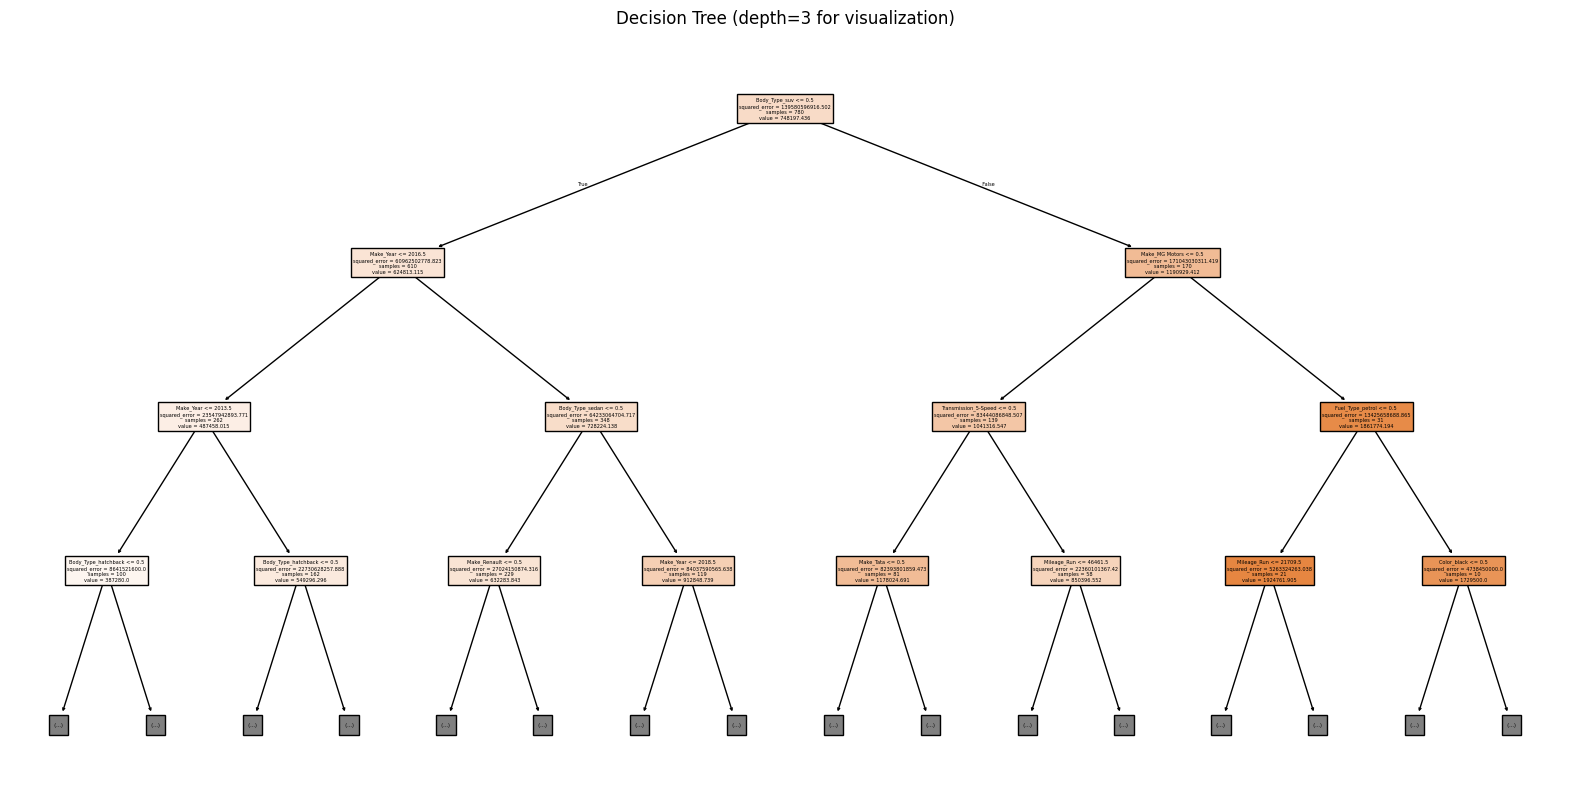

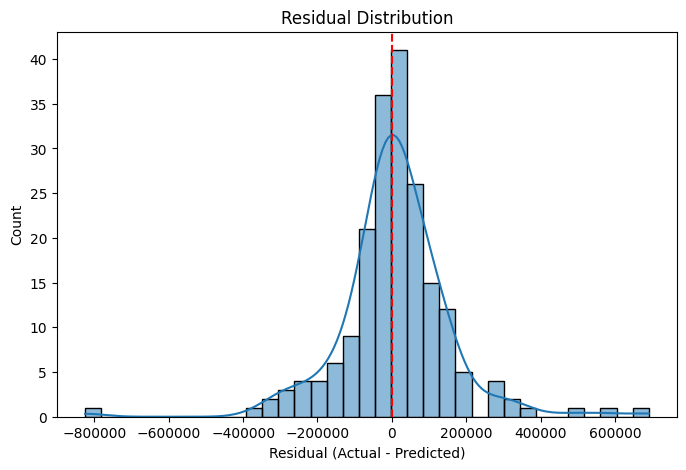

Mean of residuals: 9025.425170068025


In [24]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import r2_score, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns

model = DecisionTreeRegressor(min_samples_leaf=3, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("R² on test set:", r2)
print("RMSE on test set:", rmse)

plt.figure(figsize=(20, 10))
plot_tree(model, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree (depth=3 for visualization)")
plt.show()

residuals = y_test - y_pred
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title("Residual Distribution")
plt.xlabel("Residual (Actual - Predicted)")
plt.show()

print("Mean of residuals:", residuals.mean())



Yes, centered around 0!

In [25]:
from sklearn.linear_model import LinearRegression

linreg = LinearRegression()
linreg.fit(X_train, y_train)

y_pred_lr = linreg.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("Linear Regression - R²:", r2_lr)
print("Linear Regression - RMSE:", rmse_lr)


r2_tree = r2_score(y_test, y_pred)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred))
print("Decision Tree - R²:", r2_tree)
print("Decision Tree - RMSE:", rmse_tree)


Linear Regression - R²: 0.8202733305970802
Linear Regression - RMSE: 143575.19660662542
Decision Tree - R²: 0.8019082918926088
Decision Tree - RMSE: 150732.29268321928


To determine the best model, choose the model with higher R² and lower RMSE on the test set, so the linear regression is better.

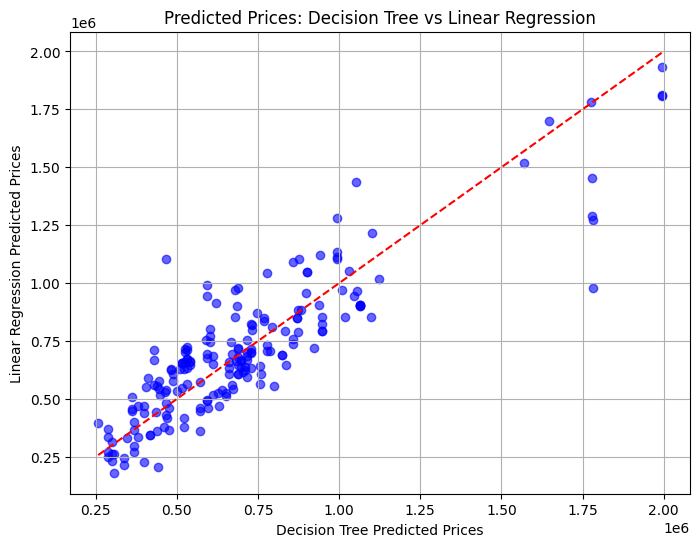

In [26]:
import matplotlib.pyplot as plt

y_pred_tree = model.predict(X_test)
y_pred_lr = linreg.predict(X_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_pred_tree, y_pred_lr, alpha=0.6, color='b')
plt.plot([min(y_pred_tree), max(y_pred_tree)], [min(y_pred_tree), max(y_pred_tree)], color='r', linestyle='--')
plt.title("Predicted Prices: Decision Tree vs Linear Regression")
plt.xlabel("Decision Tree Predicted Prices")
plt.ylabel("Linear Regression Predicted Prices")
plt.grid(True)
plt.show()


The models are both pretty good.

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$.

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [31]:
!git clone https://github.com/mvu2ab/trees.git


import pandas as pd

data1 = "trees/assignment/data/corporate_ratings.csv"
df1 = pd.read_csv(data1)
print(f"Observations: {df1.shape[0]}, Variables: {df1.shape[1]}")

print(df1.head())

fatal: destination path 'trees' already exists and is not an empty directory.
Observations: 2029, Variables: 31
  Rating                   Name Symbol                  Rating Agency Name  \
0      A  Whirlpool Corporation    WHR          Egan-Jones Ratings Company   
1    BBB  Whirlpool Corporation    WHR          Egan-Jones Ratings Company   
2    BBB  Whirlpool Corporation    WHR                       Fitch Ratings   
3    BBB  Whirlpool Corporation    WHR                       Fitch Ratings   
4    BBB  Whirlpool Corporation    WHR  Standard & Poor's Ratings Services   

         Date             Sector  currentRatio  quickRatio  cashRatio  \
0  11/27/2015  Consumer Durables      0.945894    0.426395   0.099690   
1   2/13/2014  Consumer Durables      1.033559    0.498234   0.203120   
2    3/6/2015  Consumer Durables      0.963703    0.451505   0.122099   
3   6/15/2012  Consumer Durables      1.019851    0.510402   0.176116   
4  10/24/2016  Consumer Durables      0.957844    0.49

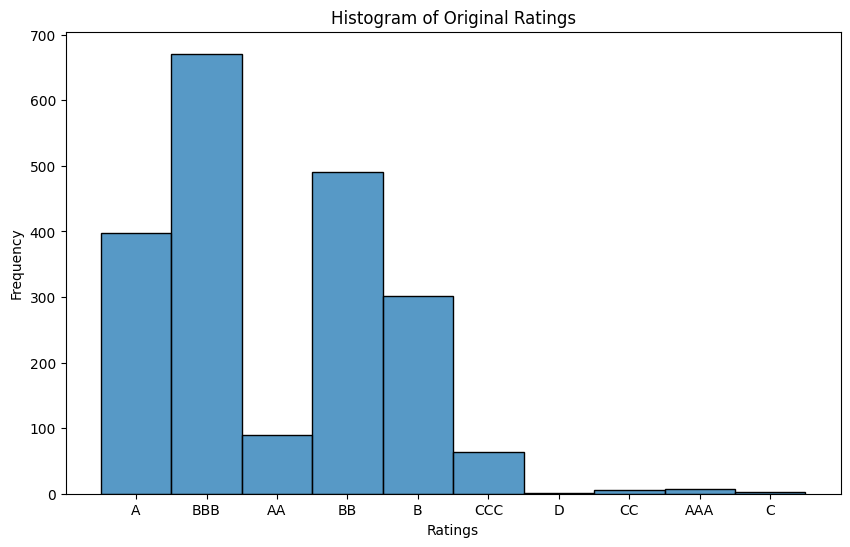

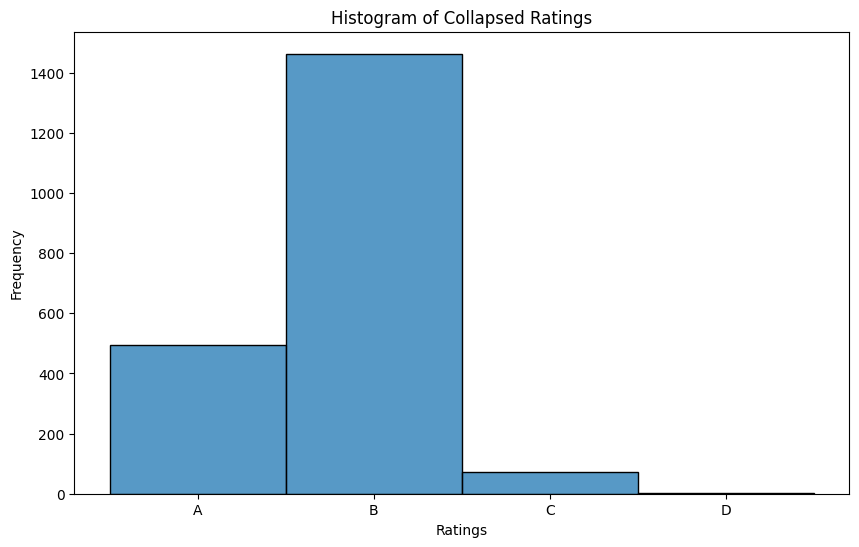

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

ratings = df1['Rating']

plt.figure(figsize=(10, 6))
sns.histplot(ratings, kde=False, bins=len(ratings.unique()))
plt.title("Histogram of Original Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()

collapsed_ratings = ratings.replace({
    'AAA': 'A', 'AA': 'A', 'A': 'A',
    'BBB': 'B', 'BB': 'B', 'B': 'B',
    'CCC': 'C', 'CC': 'C', 'C': 'C',
})


plt.figure(figsize=(10, 6))
sns.histplot(collapsed_ratings, kde=False, bins=len(collapsed_ratings.unique()))
plt.title("Histogram of Collapsed Ratings")
plt.xlabel("Ratings")
plt.ylabel("Frequency")
plt.show()


In [34]:
import pandas as pd

df_cleaned = df1.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name'])

df_encoded = pd.get_dummies(df_cleaned, columns=['Sector'], drop_first=True)


X = df_encoded


print(X.head())


   currentRatio  quickRatio  cashRatio  daysOfSalesOutstanding  \
0      0.945894    0.426395   0.099690               44.203245   
1      1.033559    0.498234   0.203120               38.991156   
2      0.963703    0.451505   0.122099               50.841385   
3      1.019851    0.510402   0.176116               41.161738   
4      0.957844    0.495432   0.141608               47.761126   

   netProfitMargin  pretaxProfitMargin  grossProfitMargin  \
0         0.037480            0.049351           0.176631   
1         0.044062            0.048857           0.175715   
2         0.032709            0.044334           0.170843   
3         0.020894           -0.012858           0.138059   
4         0.042861            0.053770           0.177720   

   operatingProfitMargin  returnOnAssets  returnOnCapitalEmployed  ...  \
0               0.061510        0.041189                 0.091514  ...   
1               0.066546        0.053204                 0.104800  ...   
2             

Accuracy: 0.3645320197044335


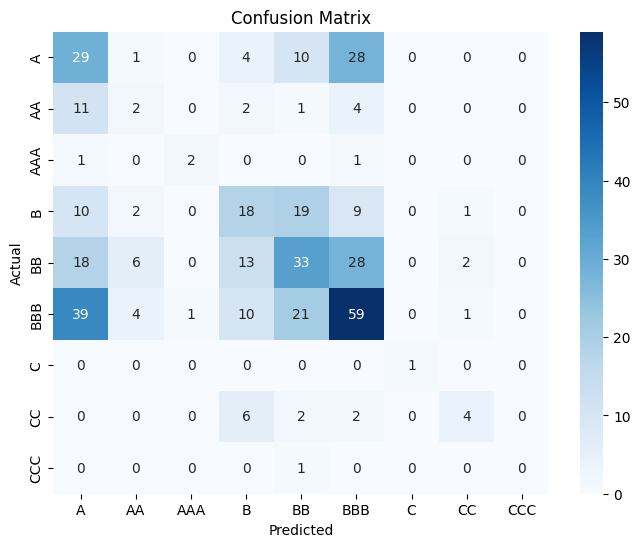

In [36]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt




X_train, X_test, y_train, y_test = train_test_split(X, df1['Rating'], test_size=0.2, random_state=42)


clf = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf.fit(X_train, y_train)


y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=clf.classes_, yticklabels=clf.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The model is pretty good actually. The values on the diagnol are typically higher than the values not on the diagnol.

Accuracy with rating agency: 0.3768472906403941


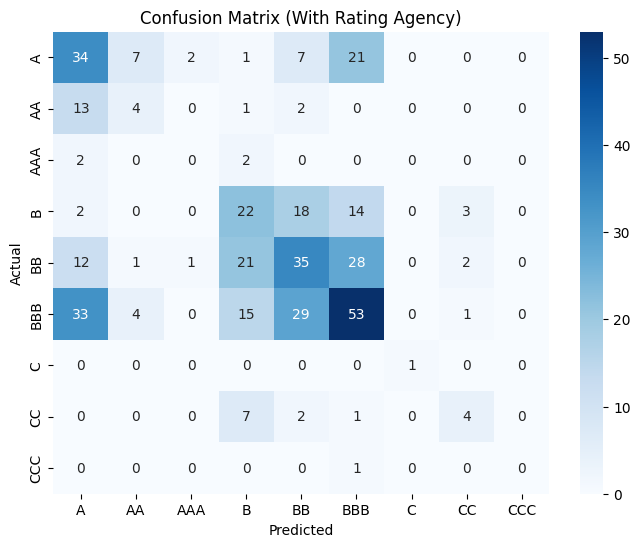

Accuracy: 0.3645320197044335
Accuracy with rating agency:    0.3768472906403941


In [38]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd


df_with_agency = df1.copy()


df_encoded_with_agency = pd.get_dummies(df_with_agency.drop(columns=['Rating', 'Date', 'Name', 'Symbol']),
                                        columns=['Sector', 'Rating Agency Name'], drop_first=True)


X_with_agency = df_encoded_with_agency
y = df1['Rating']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_with_agency, y, test_size=0.2, random_state=42)

clf_with_agency = DecisionTreeClassifier(min_samples_leaf=3, random_state=42)
clf_with_agency.fit(X_train2, y_train2)
y_pred2 = clf_with_agency.predict(X_test2)


acc_with_agency = accuracy_score(y_test2, y_pred2)
cm_with_agency = confusion_matrix(y_test2, y_pred2)

print("Accuracy with rating agency:", acc_with_agency)


plt.figure(figsize=(8, 6))
sns.heatmap(cm_with_agency, annot=True, fmt='d', cmap='Blues', xticklabels=clf_with_agency.classes_, yticklabels=clf_with_agency.classes_)
plt.title("Confusion Matrix (With Rating Agency)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


print("Accuracy:", accuracy)
print("Accuracy with rating agency:   ", acc_with_agency)


The accuracy slightly increases when including another variable. Shows more external confounding variables produce same/greater accuracy.